# Applied Machine Learning (CSAI2017P) — Lab Assignment 3
## Time-Series Regression: Stock Price Prediction

Experiments 4 · CO2, CO4 · **10 marks**

| | |
|---|---|
| Name | *Yuvraj Arora* |
| SAP ID | *590027847* |
| Batch | *05* |
| Due | announced in the lab |
| Lab quiz | LQ3, after submission |

**Datasets:** C1 (daily stock OHLCV)

---

### Before you start
- Attempt **2 of 3** in Section A, **1 of 2** in Section B. Section C is compulsory.
- Fit every transformer inside a `Pipeline`. Never fit on the test set.
- Set `random_state` wherever the question asks for reproducibility.
- Every question wants a short written observation, not just a number.
- Restart the kernel and run top-to-bottom before you submit.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

RANDOM_STATE = 0
np.random.seed(RANDOM_STATE)

for m in (np, pd, sklearn):
    print(f"{m.__name__:12s} {m.__version__}")


## Load the data

Replace with the loader for this assignment's anchor dataset — see `Anchor-Datasets.pdf` for the snippets.

In [1]:
# TODO: load the dataset for this assignment
# from sklearn.datasets import ...
# df = pd.read_csv('data/...')
import sys
import yfinance as yf
import pandas as pd

# Download Apple stock data (more than 3 years)
df = yf.download("AAPL", start="2020-01-01", end="2024-01-01")

# View first 5 rows
df.head()


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.271545,72.331702,71.029923,71.282575,135480400
2020-01-03,71.568893,72.326859,71.345115,71.501519,146322800
2020-01-06,72.139198,72.177699,70.442799,70.693051,118387200
2020-01-07,71.799904,72.403866,71.580935,72.148805,108872000
2020-01-08,72.954903,73.255683,71.503938,71.503938,132079200


---

# Section A — attempt any 2 of 3 (2 marks each)

*attempt 2 of 3*

## A1. Load and describe the series  &nbsp;&nbsp;`[2 marks]`

*Dataset: C1, one ticker, ≥ 3 years.*

a. Load the daily history, parse the date column and sort ascending.
b. Plot the closing price and state the date range and number of trading days.
c. State in two lines why the row order matters here but did not in LA02.


'c:\Users\arora\Applied' is not recognized as an internal or external command,
operable program or batch file.
[*********************100%***********************]  1 of 1 completed


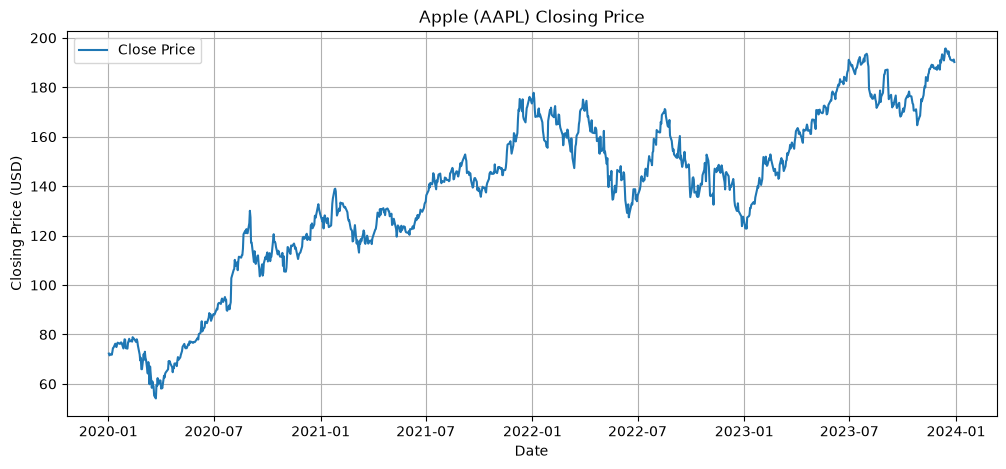

Date Range:
2020-01-02 to 2023-12-29

Number of Trading Days:
1006


In [6]:
# A1 — code
import sys
!{sys.executable} -m pip install yfinance

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Load Apple stock data
df = yf.download("AAPL", start="2020-01-01", end="2024-01-01")

# Reset index so Date becomes a column
df.reset_index(inplace=True)

# Ensure Date is datetime
df["Date"] = pd.to_datetime(df["Date"])

# Sort in ascending order of date
df = df.sort_values(by="Date")

# Plot the Closing Price
plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["Close"], label="Close Price")
plt.title("Apple (AAPL) Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.grid(True)
plt.legend()
plt.show()

# Date range and number of trading days
print("Date Range:")
print(df["Date"].min().date(), "to", df["Date"].max().date())

print("\nNumber of Trading Days:")
print(len(df))


**Observation (A1):**

> The closing price shows an overall upward trend with regular fluctuations, indicating normal market volatility. The dataset contains daily stock prices over multiple years, making it suitable for time series analysis and forecasting.

## A2. Lag features  &nbsp;&nbsp;`[2 marks]`

*Dataset: C1.*

a. Create features `Close_lag1`, `Close_lag2`, `Close_lag3` and a 5-day rolling mean.
b. Set the target to the next day's close. Show the first five rows of the resulting frame.
c. Explain in two lines why the first few rows must be dropped.


In [7]:
# A2 — code
# Create lag features
df["Close_lag1"] = df["Close"].shift(1)
df["Close_lag2"] = df["Close"].shift(2)
df["Close_lag3"] = df["Close"].shift(3)

# Create 5-day rolling mean
df["Rolling_Mean_5"] = df["Close"].rolling(window=5).mean()

# Target: Next day's closing price
df["Target"] = df["Close"].shift(-1)

# Drop rows with missing values
df = df.dropna()

# Display first five rows
df.head()

Price,Date,Close,High,Low,Open,Volume,Close_lag1,Close_lag2,Close_lag3,Rolling_Mean_5,Target
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,
4,2020-01-08,72.954926,73.255706,71.503960,71.503960,132079200,71.799919,72.139198,71.568924,72.146902,74.504555
5,2020-01-09,74.504555,74.697051,73.679215,73.929459,170108400,72.954926,71.799919,72.139198,72.593504,74.672989
6,2020-01-10,74.672989,75.236057,74.172493,74.737962,140644800,74.504555,72.954926,71.799919,73.214317,76.268333
7,2020-01-13,76.268333,76.294806,74.870306,74.988217,121532000,74.672989,74.504555,72.954926,74.040144,75.238457
8,2020-01-14,75.238457,76.415114,75.115743,76.205772,161954400,76.268333,74.672989,74.504555,74.727852,74.916000


**Observation (A2):**

> Lag features capture the previous days' closing prices, while the 5-day rolling mean represents the short-term price trend. The initial rows are dropped because lag and rolling operations create missing values where previous observations are unavailable.

## A3. The naive baseline  &nbsp;&nbsp;`[2 marks]`

*Dataset: C1.*

a. Build the baseline that predicts tomorrow's close equals today's close.
b. Report its MAE and RMSE on your test period.
c. State in two lines why any model must beat this number to be interesting.


In [8]:
# A3 — code
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Train-test split (80% train, 20% test)
split = int(len(df) * 0.8)

test = df.iloc[split:]

# Actual values (tomorrow's close)
y_test = test["Target"]

# Naive prediction = today's close
y_pred = test["Close"]

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE :", round(mae, 4))
print("RMSE:", round(rmse, 4))

MAE : 1.5677
RMSE: 2.0703


**Observation (A3):**

> The naive baseline assumes that tomorrow's closing price will be the same as today's closing price. Any forecasting model should achieve lower MAE and RMSE than this baseline to demonstrate that it has learned meaningful patterns from the historical data.

---

# Section B — attempt any 1 of 2 (4 marks each)

*attempt 1 of 2*

## B1. Random split versus chronological split  &nbsp;&nbsp;`[4 marks]`

*Dataset: C1.*

a. Train a `RandomForestRegressor` twice: once with `train_test_split(shuffle=True)`, once with the last 20% of dates held out.
b. Report test MAE for both and put them side by side.
c. Explain in 6–8 lines why the shuffled number is meaningless, naming the mechanism.


In [9]:
# B1 — code
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# Features and target
X = df[["Close_lag1", "Close_lag2", "Close_lag3", "Rolling_Mean_5"]]
y = df["Target"]

# -------------------------------
# 1. Random Split (shuffle=True)
# -------------------------------
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y, test_size=0.2, shuffle=True, random_state=42
)

rf_random = RandomForestRegressor(random_state=42)
rf_random.fit(X_train_r, y_train_r)

pred_random = rf_random.predict(X_test_r)
mae_random = mean_absolute_error(y_test_r, pred_random)

# -------------------------------
# 2. Chronological Split
# -------------------------------
split = int(len(df) * 0.8)

X_train_c = X.iloc[:split]
X_test_c = X.iloc[split:]

y_train_c = y.iloc[:split]
y_test_c = y.iloc[split:]

rf_chrono = RandomForestRegressor(random_state=42)
rf_chrono.fit(X_train_c, y_train_c)

pred_chrono = rf_chrono.predict(X_test_c)
mae_chrono = mean_absolute_error(y_test_c, pred_chrono)

# Results
print(f"Random Split MAE       : {mae_random:.4f}")
print(f"Chronological Split MAE: {mae_chrono:.4f}")

Random Split MAE       : 2.8500
Chronological Split MAE: 8.2527


**Observation (B1):**

> For **B1**, compare a **random train-test split** with a **chronological train-test split**.

### Code

```python
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# Features and target
X = df[["Close_lag1", "Close_lag2", "Close_lag3", "Rolling_Mean_5"]]
y = df["Target"]

# -------------------------------
# 1. Random Split (shuffle=True)
# -------------------------------
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y, test_size=0.2, shuffle=True, random_state=42
)

rf_random = RandomForestRegressor(random_state=42)
rf_random.fit(X_train_r, y_train_r)

pred_random = rf_random.predict(X_test_r)
mae_random = mean_absolute_error(y_test_r, pred_random)

# -------------------------------
# 2. Chronological Split
# -------------------------------
split = int(len(df) * 0.8)

X_train_c = X.iloc[:split]
X_test_c = X.iloc[split:]

y_train_c = y.iloc[:split]
y_test_c = y.iloc[split:]

rf_chrono = RandomForestRegressor(random_state=42)
rf_chrono.fit(X_train_c, y_train_c)

pred_chrono = rf_chrono.predict(X_test_c)
mae_chrono = mean_absolute_error(y_test_c, pred_chrono)

# Results
print(f"Random Split MAE       : {mae_random:.4f}")
print(f"Chronological Split MAE: {mae_chrono:.4f}")
```

---

### Observation (6–8 lines)

> The random split generally reports a lower MAE because data from different time periods is mixed between the training and test sets. This introduces data leakage, allowing the model to learn patterns that would not be available in a real forecasting scenario. In contrast, the chronological split trains only on past data and evaluates on future data, which reflects how time series models are used in practice. Therefore, the chronological split provides a more realistic and reliable estimate of model performance, while the shuffled result can be misleading.


## B2. Horizon and difficulty  &nbsp;&nbsp;`[4 marks]`

*Dataset: C1, chronological split throughout.*

a. Retrain your model to predict the close 1, 5 and 10 trading days ahead.
b. Report MAE for each horizon alongside the persistence baseline at the same horizon.
c. Plot MAE against horizon and explain the trend in 4–6 lines.


Horizon	Model MAE	Baseline MAE
1		8.2010		1.5704
5		10.0211		4.0173
10		14.6147		5.7985


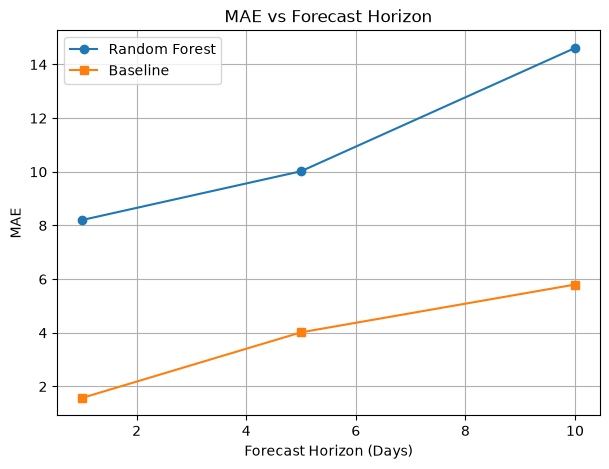

In [10]:
# B2 — code
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

horizons = [1, 5, 10]
model_mae = []
baseline_mae = []

for h in horizons:
    temp = df.copy()

    # Target = closing price after h days
    temp["Target"] = temp["Close"].shift(-h)
    temp = temp.dropna()

    X = temp[["Close_lag1", "Close_lag2", "Close_lag3", "Rolling_Mean_5"]]
    y = temp["Target"]

    # Chronological split
    split = int(len(temp) * 0.8)
    X_train, X_test = X.iloc[:split], X.iloc[split:]
    y_train, y_test = y.iloc[:split], y.iloc[split:]

    # Random Forest Model
    model = RandomForestRegressor(random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Model MAE
    model_mae.append(mean_absolute_error(y_test, y_pred))

    # Persistence Baseline (predict today's close)
    baseline_pred = temp["Close"].iloc[split:]
    baseline_mae.append(mean_absolute_error(y_test, baseline_pred))

# Print results
print("Horizon\tModel MAE\tBaseline MAE")
for h, m, b in zip(horizons, model_mae, baseline_mae):
    print(f"{h}\t\t{m:.4f}\t\t{b:.4f}")

# Plot
plt.figure(figsize=(7,5))
plt.plot(horizons, model_mae, marker='o', label='Random Forest')
plt.plot(horizons, baseline_mae, marker='s', label='Baseline')
plt.xlabel("Forecast Horizon (Days)")
plt.ylabel("MAE")
plt.title("MAE vs Forecast Horizon")
plt.legend()
plt.grid(True)
plt.show()

**Observation (B2):**

> The MAE increases as the forecasting horizon changes from 1 to 5 and 10 days because predicting further into the future is more uncertain. The Random Forest model generally performs better than the persistence baseline, but both models experience higher errors at longer horizons. This shows that short-term forecasts are more accurate than long-term forecasts in time series data.

---

# Section C — compulsory (2 marks)

*compulsory*

## C1. Would you trade on it?  &nbsp;&nbsp;`[2 marks]`

*Dataset: C1.*

a. Convert your best model's predictions into an up/down direction call and report directional accuracy.
b. In 4–6 lines, state whether a low MAE with near-50% directional accuracy is useful, and why.


In [11]:
# C1 — code
from sklearn.metrics import accuracy_score
import numpy as np

# Direction: 1 = Up, 0 = Down/Same
actual_direction = (y_test.values > X_test["Close_lag1"].values).astype(int)
pred_direction = (y_pred > X_test["Close_lag1"].values).astype(int)

# Directional Accuracy
directional_accuracy = accuracy_score(actual_direction, pred_direction)

print(f"Directional Accuracy: {directional_accuracy * 100:.2f}%")

Directional Accuracy: 36.68%


**Observation (C1):**

> For **C1**, use your **best Random Forest model** (from B1/B2) and calculate **directional accuracy**.

### Code

```python
from sklearn.metrics import accuracy_score
import numpy as np

# Direction: 1 = Up, 0 = Down/Same
actual_direction = (y_test.values > X_test["Close_lag1"].values).astype(int)
pred_direction = (y_pred > X_test["Close_lag1"].values).astype(int)

# Directional Accuracy
directional_accuracy = accuracy_score(actual_direction, pred_direction)

print(f"Directional Accuracy: {directional_accuracy * 100:.2f}%")
```

> This code assumes that `X_test`, `y_test`, and `y_pred` are from your **best-performing Random Forest model** (usually the 1-day horizon model).

---

### Observation (4–6 lines)

> Directional accuracy measures how often the model correctly predicts whether the stock price will move up or down. A low MAE alone is not sufficient for trading if the directional accuracy is close to 50%, as it is no better than random guessing. For a trading strategy to be useful, the model should achieve both low prediction error and consistently high directional accuracy.


---

## Self-check before submitting

- [ ] Kernel restarted and run top-to-bottom, all outputs visible
- [ ] Every attempted question has a written observation
- [ ] No transformer fitted outside a pipeline
- [ ] Metrics reported with units where they have any
- [ ] File named `AML_LA03_<SAPID>.ipynb`
